1D Helmholtz Equation - Finite Difference Method Solver

Problem Parameters:
  Domain: [-1.0, 1.0]
  Grid points: 101
  Grid spacing: 0.0200
  Wave number k²: 1.0000+0.0000j

Solving Helmholtz equation...
Note: Solution is complex. Max imaginary part: 0.00e+00
Solution computed successfully!

Evaluation Metrics:
------------------------------
  MSE         : 4.050591e-09
  RMSE        : 6.364425e-05
  MAE         : 5.615225e-05
  MAX_ERROR   : 9.989604e-05
  RELATIVE_L2 : 5.187746e-05

Generating comparison plots...


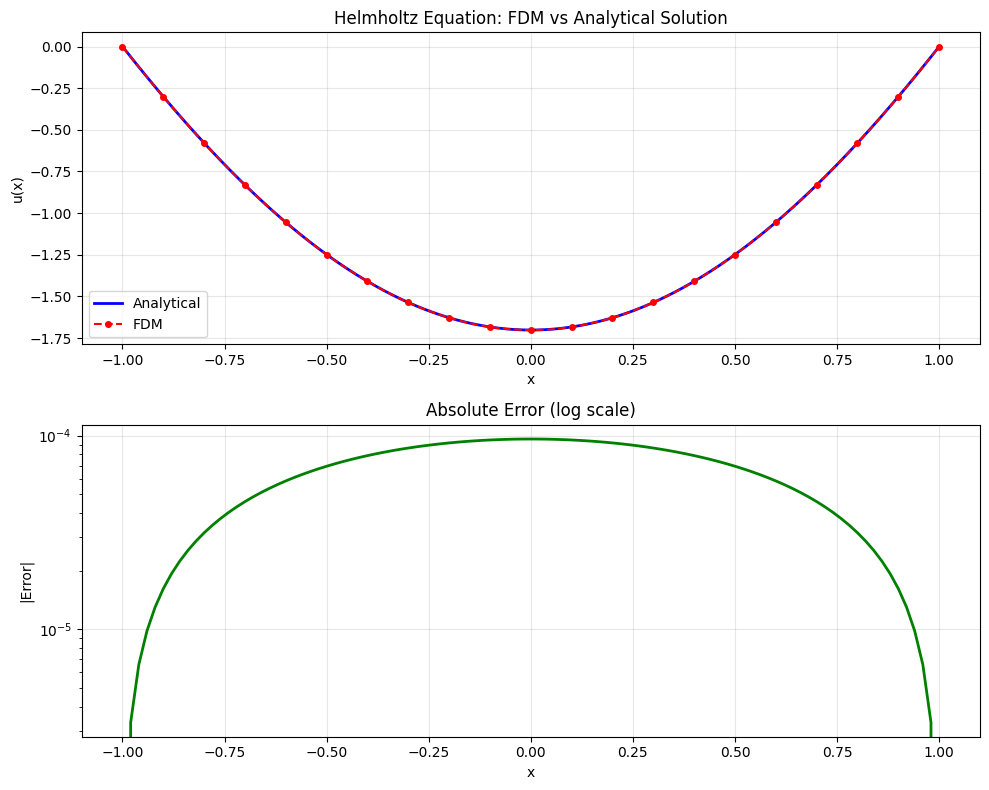


Performing convergence study...
Note: Solution is complex. Max imaginary part: 0.00e+00
Note: Solution is complex. Max imaginary part: 0.00e+00
Note: Solution is complex. Max imaginary part: 0.00e+00
Note: Solution is complex. Max imaginary part: 0.00e+00
Note: Solution is complex. Max imaginary part: 0.00e+00
Note: Solution is complex. Max imaginary part: 0.00e+00


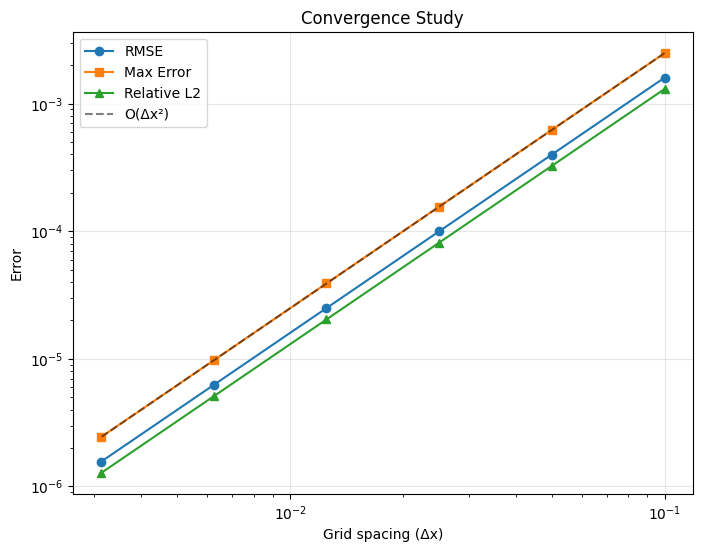


Convergence Results:
--------------------------------------------------
  N Points         Δx         RMSE    Max Error
--------------------------------------------------
        21     0.1000   1.5993e-03   2.4890e-03
        41     0.0500   3.9927e-04   6.2312e-04
        81     0.0250   9.9852e-05   1.5589e-04
       161     0.0125   2.4963e-05   3.8988e-05
       321     0.0063   6.2406e-06   9.7272e-06
       641     0.0031   1.5600e-06   2.4355e-06

Estimated convergence rate: 2.00 (theoretical: 2.00)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

class HelmholtzFDMSolver:
    """
    Finite Difference Method solver for 1D inhomogeneous Helmholtz equation.

    Solves: (∇² + k²)u(x) = f(x) on domain [a, b]
    with Dirichlet boundary conditions: u(a) = u(b) = 0
    """

    def __init__(self,
                 domain: Tuple[float, float] = (-1.0, 1.0),
                 n_points: int = 101,
                 source_func: Optional[callable] = None,
                 analytical_solution: Optional[callable] = None,
                 G_prime: float = 1.0,
                 G_double_prime: float = 0.0,
                 rho: float = 1.0,
                 omega: float = 1.0):
        """
        Initialize the FDM solver.

        Args:
            domain: Computational domain [a, b]
            n_points: Number of grid points
            source_func: Source term function f(x)
            analytical_solution: Analytical solution for comparison
            G_prime: Storage modulus
            G_double_prime: Loss modulus
            rho: Density
            omega: Angular frequency
        """
        self.domain = domain
        self.n_points = n_points
        self.G_prime = G_prime
        self.G_double_prime = G_double_prime
        self.rho = rho
        self.omega = omega

        # Default source function
        if source_func is None:
            self.source_func = lambda x: 2.0 * np.ones_like(x)
        else:
            self.source_func = source_func

        # Analytical solution
        if analytical_solution is None:
            self.analytical_solution = lambda x: 2.0 * (1 - np.cos(x) / np.cos(1))
        else:
            self.analytical_solution = analytical_solution

        # Wave number
        self.k_squared = self._compute_wave_number()

        # Setup grid
        self.x_grid = np.linspace(domain[0], domain[1], n_points)
        self.dx = (domain[1] - domain[0]) / (n_points - 1)

        # Solution placeholder
        self.u_solution = None

    def _compute_wave_number(self) -> complex:
        """Compute the squared wave number k²."""
        k_squared = (self.rho * self.omega**2) / (self.G_prime + 1j * self.G_double_prime)
        return k_squared

    def build_system(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Build the linear system Au = b for the FDM discretization.

        Returns:
            A: Coefficient matrix
            b: Right-hand side vector
        """
        n = self.n_points
        dx2 = self.dx**2

        # Build tridiagonal matrix using sparse representation
        # Interior points: u_{i-1} - (2 - k²Δx²)u_i + u_{i+1} = f_i Δx²
        main_diag = -(2.0 - self.k_squared * dx2) * np.ones(n)
        # Use separate off-diagonals so we only zero true boundary couplings
        upper = np.ones(n - 1)  # A[i, i+1]
        lower = np.ones(n - 1)  # A[i, i-1]

        # Apply boundary conditions
        main_diag[0] = 1.0
        main_diag[-1] = 1.0
        upper[0] = 0.0        # zero A[0,1]
        lower[-1] = 0.0       # zero A[n-1,n-2]

        # Create sparse tridiagonal matrix
        A = diags([lower, main_diag, upper], [-1, 0, 1], shape=(n, n), format='csr')

        # Right-hand side
        b = self.source_func(self.x_grid) * dx2

        # Apply boundary conditions
        b[0] = 0.0  # u(-1) = 0
        b[-1] = 0.0  # u(1) = 0

        return A, b

    def solve(self) -> np.ndarray:
        """
        Solve the Helmholtz equation using FDM.

        Returns:
            u_solution: Numerical solution at grid points
        """
        A, b = self.build_system()

        self.u_solution = spsolve(A, b)

        # If k² is complex
        if np.iscomplexobj(self.u_solution):
            print(f"Note: Solution is complex. Max imaginary part: {np.max(np.abs(np.imag(self.u_solution))):.2e}")
            # For visualization, we'll use the real part
            self.u_solution = np.real(self.u_solution)

        return self.u_solution

    def predict(self, x_test: np.ndarray) -> np.ndarray:
        """
        Interpolate solution at test points.

        Args:
            x_test: Test points for evaluation

        Returns:
            Interpolated solution values
        """
        if self.u_solution is None:
            raise ValueError("Solution not computed yet. Call solve() first.")

        # Simple linear interpolation
        return np.interp(x_test.flatten(), self.x_grid, self.u_solution)

    def compute_metrics(self,
                       x_test: np.ndarray = None,
                       metrics: List[str] = None) -> Dict[str, float]:
        """
        Compute evaluation metrics comparing FDM solution with analytical solution.

        Args:
            x_test: Test points (if None, uses uniform grid)
            metrics: List of metric names to compute

        Returns:
            Dictionary of metric values
        """
        if metrics is None:
            metrics = ["mse", "rmse", "mae", "max_error", "relative_l2"]

        if x_test is None:
            x_test = np.linspace(self.domain[0], self.domain[1], 1000)

        x_test = x_test.reshape(-1, 1) if x_test.ndim == 1 else x_test

        # Get predictions and true values
        u_pred = self.predict(x_test).flatten()
        u_true = self.analytical_solution(x_test).flatten()

        # Define metric functions
        metric_functions = {
            "mse": lambda y_true, y_pred: np.mean((y_true - y_pred)**2),
            "rmse": lambda y_true, y_pred: np.sqrt(np.mean((y_true - y_pred)**2)),
            "mae": lambda y_true, y_pred: np.mean(np.abs(y_true - y_pred)),
            "max_error": lambda y_true, y_pred: np.max(np.abs(y_true - y_pred)),
            "r2": lambda y_true, y_pred: 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2),
            "relative_l2": lambda y_true, y_pred: np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
        }

        # Compute requested metrics
        results = {}
        for metric in metrics:
            if metric in metric_functions:
                results[metric] = metric_functions[metric](u_true, u_pred)
            else:
                print(f"Warning: Metric '{metric}' not implemented")

        return results

    def plot_solution(self, save_path: str = None, show_plot: bool = True):
        """
        Plot the FDM solution compared with analytical solution.

        Args:
            save_path: Path to save the figure
            show_plot: Whether to display the plot
        """
        if self.u_solution is None:
            raise ValueError("Solution not computed yet. Call solve() first.")

        # Create fine grid for smooth analytical solution
        x_fine = np.linspace(self.domain[0], self.domain[1], 1000)
        u_analytical = self.analytical_solution(x_fine)

        # Create figure with subplots
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # Plot 1: Solutions comparison
        axes[0].plot(x_fine, u_analytical, 'b-', label='Analytical', linewidth=2)
        axes[0].plot(self.x_grid, self.u_solution, 'ro--', label='FDM',
                    markersize=4, markevery=max(1, self.n_points//20))
        axes[0].set_xlabel('x')
        axes[0].set_ylabel('u(x)')
        axes[0].set_title('Helmholtz Equation: FDM vs Analytical Solution')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot 2: Error
        u_analytical_grid = self.analytical_solution(self.x_grid)
        error = np.abs(self.u_solution - u_analytical_grid)
        axes[1].semilogy(self.x_grid, error, 'g-', linewidth=2)
        axes[1].set_xlabel('x')
        axes[1].set_ylabel('|Error|')
        axes[1].set_title('Absolute Error (log scale)')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')

        if show_plot:
            plt.show()

        return fig

    def convergence_study(self, n_points_list: List[int] = None) -> Dict:
        """
        Perform convergence study with different grid resolutions.

        Args:
            n_points_list: List of grid point numbers to test

        Returns:
            Dictionary with convergence results
        """
        if n_points_list is None:
            n_points_list = [21, 41, 81, 161, 321, 641]

        results = {
            'n_points': [],
            'dx': [],
            'rmse': [],
            'max_error': [],
            'relative_l2': []
        }

        original_n = self.n_points

        for n in n_points_list:
            # Update grid
            self.n_points = n
            self.x_grid = np.linspace(self.domain[0], self.domain[1], n)
            self.dx = (self.domain[1] - self.domain[0]) / (n - 1)

            # Solve
            self.solve()

            # Compute metrics
            metrics = self.compute_metrics(metrics=["rmse", "max_error", "relative_l2"])

            results['n_points'].append(n)
            results['dx'].append(self.dx)
            results['rmse'].append(metrics['rmse'])
            results['max_error'].append(metrics['max_error'])
            results['relative_l2'].append(metrics['relative_l2'])

        # Restore original grid
        self.n_points = original_n
        self.x_grid = np.linspace(self.domain[0], self.domain[1], original_n)
        self.dx = (self.domain[1] - self.domain[0]) / (original_n - 1)

        # Plot convergence
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.loglog(results['dx'], results['rmse'], 'o-', label='RMSE')
        ax.loglog(results['dx'], results['max_error'], 's-', label='Max Error')
        ax.loglog(results['dx'], results['relative_l2'], '^-', label='Relative L2')

        # Add reference slope for second-order convergence
        dx_array = np.array(results['dx'])
        reference_line = results['max_error'][0] * (dx_array / dx_array[0])**2
        ax.loglog(dx_array, reference_line, 'k--', alpha=0.5, label='O(Δx²)')

        ax.set_xlabel('Grid spacing (Δx)')
        ax.set_ylabel('Error')
        ax.set_title('Convergence Study')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

        return results


def main():
    """Main function to demonstrate the FDM solver."""

    print("=" * 60)
    print("1D Helmholtz Equation - Finite Difference Method Solver")
    print("=" * 60)

    # Initialize solver with benchmark problem parameters
    solver = HelmholtzFDMSolver(
        domain=(-1.0, 1.0),
        n_points=101,
        G_prime=1.0,
        G_double_prime=0.0,
        rho=1.0,
        omega=1.0
    )

    print(f"\nProblem Parameters:")
    print(f"  Domain: [{solver.domain[0]}, {solver.domain[1]}]")
    print(f"  Grid points: {solver.n_points}")
    print(f"  Grid spacing: {solver.dx:.4f}")
    print(f"  Wave number k²: {solver.k_squared:.4f}")

    # Solve the equation
    print("\nSolving Helmholtz equation...")
    u_fdm = solver.solve()
    print("Solution computed successfully!")

    # Compute evaluation metrics
    print("\nEvaluation Metrics:")
    print("-" * 30)
    metrics = solver.compute_metrics()
    for metric_name, value in metrics.items():
        print(f"  {metric_name.upper():12s}: {value:.6e}")

    print("\nGenerating comparison plots...")
    solver.plot_solution()

    print("\nPerforming convergence study...")
    convergence_results = solver.convergence_study()

    print("\nConvergence Results:")
    print("-" * 50)
    print(f"{'N Points':>10} {'Δx':>10} {'RMSE':>12} {'Max Error':>12}")
    print("-" * 50)
    for i in range(len(convergence_results['n_points'])):
        print(f"{convergence_results['n_points'][i]:>10} "
              f"{convergence_results['dx'][i]:>10.4f} "
              f"{convergence_results['rmse'][i]:>12.4e} "
              f"{convergence_results['max_error'][i]:>12.4e}")

    # Calculate convergence rate
    if len(convergence_results['dx']) > 1:
        log_dx = np.log(convergence_results['dx'])
        log_error = np.log(convergence_results['max_error'])
        rate = np.polyfit(log_dx, log_error, 1)[0]
        print(f"\nEstimated convergence rate: {rate:.2f} (theoretical: 2.00)")

    return solver


if __name__ == "__main__":
    solver = main()